In [1]:
import pandas as pd
import numpy as np
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                              precision_score, recall_score,
                              RocCurveDisplay, ConfusionMatrixDisplay,
                              classification_report)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [2]:
X_train, X_test, y_train, y_test = joblib.load('data/train_test_split.pkl')

# Load All Models

In [3]:
 models = {}

# Load each model — comment out any not yet done by teammates
try:
    models['Logistic Regression'] = joblib.load('data/lr_model.pkl')
    print("Logistic Regression loaded")
except:
    print("Logistic Regression not found")

try:
    models['Random Forest'] = joblib.load('data/rf_model.pkl')
    print("Random Forest loaded")
except:
    print("Random Forest not found — teammate pending")

try:
    models['KNN'] = joblib.load('data/knn_model.pkl')
    print("KNN loaded")
except:
    print("KNN not found — teammate pending")

try:
    models['Decision Tree'] = joblib.load('data/dt_model.pkl')
    print("Decision Tree loaded")
except:
    print("Decision Tree not found — teammate pending")

print(f"\nModels ready: {list(models.keys())}")

Logistic Regression loaded
Random Forest not found — teammate pending
KNN not found — teammate pending
Decision Tree not found — teammate pending

Models ready: ['Logistic Regression']


#  Load Individual Results

In [4]:
all_results = []

result_files = {
    'Logistic Regression' : 'data/lr_results.pkl',
    'Random Forest'        : 'data/rf_results.pkl',
    'KNN'                  : 'data/knn_results.pkl',
    'Decision Tree'        : 'data/dt_results.pkl',
}

for name, path in result_files.items():
    try:
        result = joblib.load(path)
        all_results.append(result)
        print(f"Loaded results: {name}")
    except:
        print(f"Missing: {name} — teammate pending")

Loaded results: Logistic Regression
Missing: Random Forest — teammate pending
Missing: KNN — teammate pending
Missing: Decision Tree — teammate pending


# Comparative Metrics Table

In [5]:
# Build metrics from loaded models
metrics_list = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Prediction time
    start = time.time()
    _ = model.predict(X_test)
    pred_time = round(time.time() - start, 4)

    metrics_list.append({
        'Model'      : name,
        'Accuracy'   : round(accuracy_score(y_test, y_pred), 4),
        'Precision'  : round(precision_score(y_test, y_pred), 4),
        'Recall'     : round(recall_score(y_test, y_pred), 4),
        'F1-Score'   : round(f1_score(y_test, y_pred), 4),
        'ROC-AUC'    : round(roc_auc_score(y_test, y_prob), 4),
        'Pred Time(s)': pred_time,
    })

metrics_df = pd.DataFrame(metrics_list).sort_values('ROC-AUC', ascending=False)
print("=" * 70)
print("COMPARATIVE METRICS TABLE — ALL MODELS")
print("=" * 70)
print(metrics_df.to_string(index=False))

COMPARATIVE METRICS TABLE — ALL MODELS
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  Pred Time(s)
Logistic Regression    0.8096     0.5695  0.8476    0.6813   0.9062        0.0138


# Add Runtime & Memory from Saved Results

In [6]:
if all_results:
    runtime_df = pd.DataFrame(all_results)[
        ['model_name', 'train_time', 'peak_mem_kb', 'pred_time']
    ].rename(columns={'model_name': 'Model'})

    print("=" * 55)
    print("⚡ RUNTIME & MEMORY COMPARISON")
    print("=" * 55)
    print(runtime_df.to_string(index=False))

⚡ RUNTIME & MEMORY COMPARISON
              Model  train_time  peak_mem_kb  pred_time
Logistic Regression      0.2916     39339.04     0.0212


# ROC Curves (All Models)

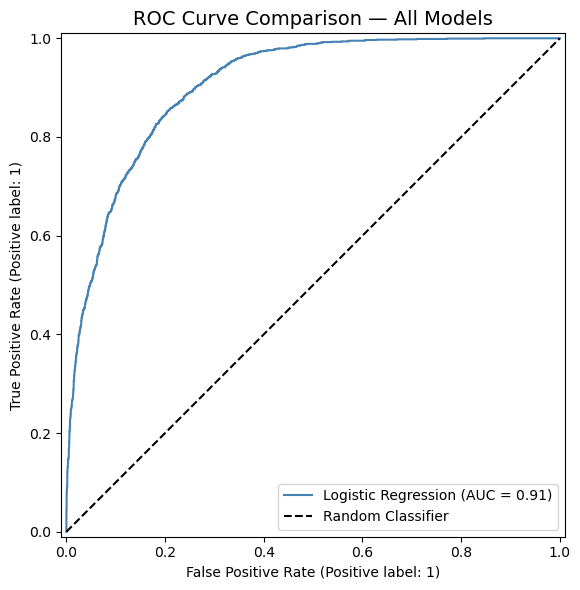

ROC curves saved!


In [7]:
fig, ax = plt.subplots(figsize=(9, 6))

colors = ['steelblue', 'coral', 'green', 'purple']
for (name, model), color in zip(models.items(), colors):
    RocCurveDisplay.from_estimator(
        model, X_test, y_test,
        ax=ax, name=name, color=color
    )

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_title('ROC Curve Comparison — All Models', fontsize=14)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('data/all_roc_curves.png', dpi=150)
plt.show()
print("ROC curves saved!")

# Confusion Matrices (All Models)

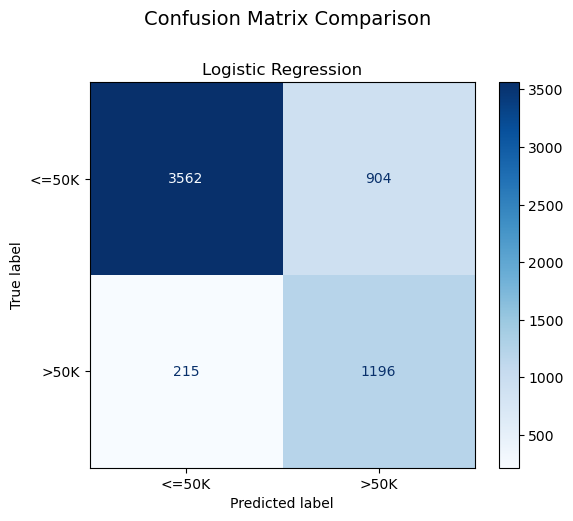

Confusion matrices saved!


In [8]:
n = len(models)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))

if n == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test,
        display_labels=['<=50K', '>50K'],
        cmap='Blues', ax=ax
    )
    ax.set_title(name, fontsize=12)

plt.suptitle('Confusion Matrix Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('data/all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices saved!")

# Accuracy Bar Chart

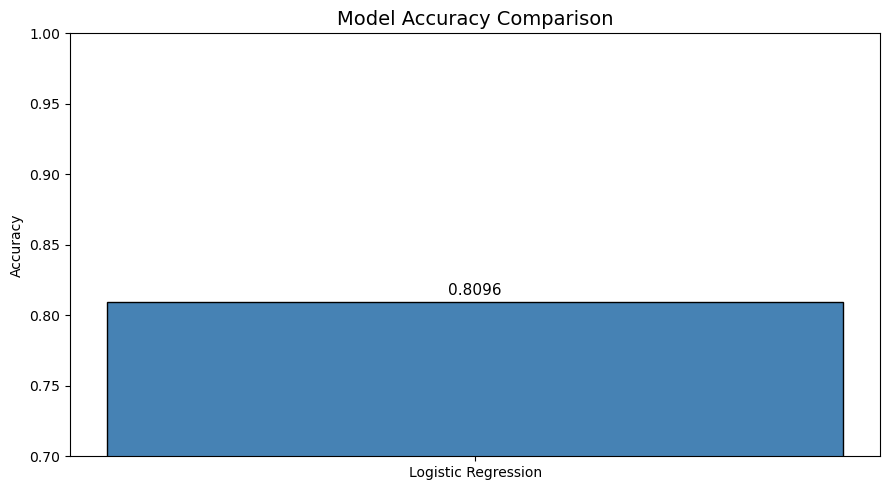

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['steelblue', 'coral', 'green', 'purple'][:len(metrics_df)]
bars = ax.bar(metrics_df['Model'], metrics_df['Accuracy'], color=colors, edgecolor='black')
ax.set_title('Model Accuracy Comparison', fontsize=14)
ax.set_ylabel('Accuracy')
ax.set_ylim(0.7, 1.0)
for bar, val in zip(bars, metrics_df['Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('data/all_accuracy_comparison.png', dpi=150)
plt.show()

#  F1 Score Bar Chart

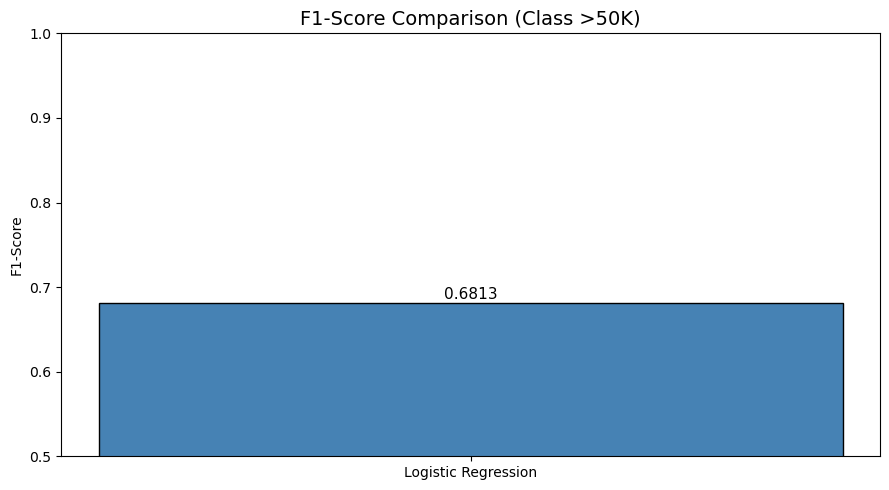

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(metrics_df['Model'], metrics_df['F1-Score'], color=colors, edgecolor='black')
ax.set_title('F1-Score Comparison (Class >50K)', fontsize=14)
ax.set_ylabel('F1-Score')
ax.set_ylim(0.5, 1.0)
for bar, val in zip(bars, metrics_df['F1-Score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('data/all_f1_comparison.png', dpi=150)
plt.show()

# Best Model Selection

In [11]:
best_model_name = metrics_df.iloc[0]['Model']
best_roc = metrics_df.iloc[0]['ROC-AUC']
best_acc = metrics_df.iloc[0]['Accuracy']
best_f1 = metrics_df.iloc[0]['F1-Score']

print("=" * 55)
print("BEST MODEL SELECTION")
print("=" * 55)
print(f"Best Model  : {best_model_name}")
print(f"ROC-AUC     : {best_roc}")
print(f"Accuracy    : {best_acc}")
print(f"F1-Score    : {best_f1}")
print("=" * 55)
print(f" {best_model_name} selected as the best model")
print("   based on highest ROC-AUC score.")

BEST MODEL SELECTION
Best Model  : Logistic Regression
ROC-AUC     : 0.9062
Accuracy    : 0.8096
F1-Score    : 0.6813
 Logistic Regression selected as the best model
   based on highest ROC-AUC score.


In [12]:
# ⚠️ RUN THIS CELL ONLY DURING DEMO with professor's hold-out CSV

# Uncomment and update path when professor provides the hold-out test set:
# holdout_df = pd.read_csv('../Data/holdout_test.csv')
# holdout_df.replace('?', np.nan, inplace=True)
# holdout_df['income'] = holdout_df['income'].str.strip()
# holdout_df['income'] = (holdout_df['income'] == '>50K').astype(int)

# numeric_cols = joblib.load('data/numeric_cols.pkl')
# categorical_cols = joblib.load('data/categorical_cols.pkl')

# X_holdout = holdout_df[numeric_cols + categorical_cols]
# y_holdout = holdout_df['income']

# best_model = models[best_model_name]
# y_holdout_pred = best_model.predict(X_holdout)
# y_holdout_prob = best_model.predict_proba(X_holdout)[:, 1]

# print("=== HOLD-OUT TEST RESULTS ===")
# print(classification_report(y_holdout, y_holdout_pred,
#       target_names=['<=50K', '>50K']))
# print(f"ROC-AUC: {roc_auc_score(y_holdout, y_holdout_prob):.4f}")

print("⚠️  Hold-out test cell ready — uncomment during demo!")

⚠️  Hold-out test cell ready — uncomment during demo!


# Final Summary

In [13]:
print("=" * 55)
print("FINAL EVALUATION COMPLETE")
print("=" * 55)
print(f"Models evaluated     : {len(models)}")
print(f"Test samples         : {len(X_test)}")
print(f"Best model           : {best_model_name}")
print(f"Best ROC-AUC         : {best_roc}")
print(f"Best Accuracy        : {best_acc}")
print("=" * 55)
print("Plots saved to notebooks/data/:")
print("  - all_roc_curves.png")
print("  - all_confusion_matrices.png")
print("  - all_accuracy_comparison.png")
print("  - all_f1_comparison.png")
print("=" * 55)

FINAL EVALUATION COMPLETE
Models evaluated     : 1
Test samples         : 5877
Best model           : Logistic Regression
Best ROC-AUC         : 0.9062
Best Accuracy        : 0.8096
Plots saved to notebooks/data/:
  - all_roc_curves.png
  - all_confusion_matrices.png
  - all_accuracy_comparison.png
  - all_f1_comparison.png
